In [1]:
import pandas as pd
import numpy as np

def clean_excel_sheet(file_path, sheet_name, year_start):
    # Reads the specific sheet
    print(f"Reading sheet {sheet_name}...")
    df_raw = pd.read_excel(file_path, sheet_name=sheet_name, header=None)
    
    # Keeps only numeric rows
    df_raw = df_raw[pd.to_numeric(df_raw[0], errors='coerce').notnull()]
    
    # Flattens the data into a single column
    data_matrix = df_raw.astype(float).values
    pf_flattened = data_matrix.flatten()
    
    # Creates dates: NOTE the lowercase 'h' in freq='h'
    start_date = f"{year_start}-01-01 00:00:00"
    timestamps = pd.date_range(start=start_date, periods=len(pf_flattened), freq='h')
    
    return pd.DataFrame({'timestamp': timestamps, 'power_factor': pf_flattened})

# The file name already in your folder
file_excel = "_New England Load Data.xls"

# The sheet names we need to extract
sheets = {
    2000: "loadrate2000T",
    2001: "loadrate2001T",
    2002: "loadrate2002T"
}

all_years = []
for year, sheet in sheets.items():
    all_years.append(clean_excel_sheet(file_excel, sheet, year))

# Merges the three years
df_final = pd.concat(all_years).reset_index(drop=True)

# Saves the cleaned result
df_final.to_csv("pf_triennio_completo.csv", index=False)

print("Finished! Created pf_triennio_completo.csv with", len(df_final), "rows.")
display(df_final.head())

Reading sheet loadrate2000T...
Reading sheet loadrate2001T...
Reading sheet loadrate2002T...
Finished! Created pf_triennio_completo.csv with 26280 rows.


,timestamp,power_factor
0,2000-01-01 00:00:00,0.471522
1,2000-01-01 01:00:00,0.444554
2,2000-01-01 02:00:00,0.421838
3,2000-01-01 03:00:00,0.410591
4,2000-01-01 04:00:00,0.408134


In [2]:
import pandas as pd
import numpy as np

# 1. Load the Power Factor dataset you just created
print("Loading Power Factor data...")
df_pf = pd.read_csv("pf_triennio_completo.csv", parse_dates=["timestamp"])

# 2. Load weather data
print("Loading Weather data...")
# Skip the first 3 rows because the real header is at row 3
df_weather = pd.read_csv("temperatura_newengland.csv", skiprows=3, parse_dates=["time"])

# Rename columns using the EXACT name found in your file
df_weather = df_weather.rename(columns={
    "time": "timestamp", 
    "temperature_2m (°C)": "temperature"
})

# 3. Merge the datasets
print("Aligning datasets temporally...")
df = pd.merge(df_pf, df_weather[['timestamp', 'temperature']], on="timestamp", how="inner")

# 4. Feature Engineering
print("Creating temporal and cyclic features...")
df['hour'] = df['timestamp'].dt.hour
df['month'] = df['timestamp'].dt.month
df['day_of_week'] = df['timestamp'].dt.dayofweek
df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)

# Sine and Cosine transformations
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

# 5. Strict Quality Control
print("\n--- DATA QUALITY REPORT ---")
print(f"Total rows expected for 3 years: about 26,280. Rows obtained: {len(df)}")
print("Missing values per column (should all be zero):")
print(df.isnull().sum())

# Save the final dataset
df.to_csv("dataset_ml_pronto.csv", index=False)
print("\nGreat job! Final dataset saved as 'dataset_ml_pronto.csv'")
display(df.head())

Loading Power Factor data...
Loading Weather data...
Aligning datasets temporally...
Creating temporal and cyclic features...

--- DATA QUALITY REPORT ---
Total rows expected for 3 years: about 26,280. Rows obtained: 26280
Missing values per column (should all be zero):
timestamp       0
power_factor    0
temperature     0
hour            0
month           0
day_of_week     0
is_weekend      0
hour_sin        0
hour_cos        0
month_sin       0
month_cos       0
dtype: int64

Great job! Final dataset saved as 'dataset_ml_pronto.csv'


,timestamp,power_factor,temperature,hour,month,day_of_week,is_weekend,hour_sin,hour_cos,month_sin,month_cos
0,2000-01-01 00:00:00,0.471522,-3.2,0,1,5,1,0.000000,1.000000,0.5,0.866025
1,2000-01-01 01:00:00,0.444554,-3.0,1,1,5,1,0.258819,0.965926,0.5,0.866025
2,2000-01-01 02:00:00,0.421838,-2.8,2,1,5,1,0.500000,0.866025,0.5,0.866025
3,2000-01-01 03:00:00,0.410591,-3.2,3,1,5,1,0.707107,0.707107,0.5,0.866025
4,2000-01-01 04:00:00,0.408134,-3.4,4,1,5,1,0.866025,0.500000,0.5,0.866025


Loading dataset...
Splitting data into Training (past) and Test (future)...
Training data: 17520 hours (Years 2000-2001)
Test data: 8760 hours (Year 2002)

Training the Model... (this may take 10 to 30 seconds)

--- BASELINE RESULTS (RANDOM FOREST) ---
MAE (Mean Absolute Error): 0.0266
RMSE (Root Mean Squared Error): 0.0370
R² (Coefficient of Determination): 0.8783

--- FEATURE IMPORTANCE ---
hour_sin       0.3138
hour_cos       0.2959
temperature    0.2494
day_of_week    0.0724
month_sin      0.0267
month_cos      0.0237
is_weekend     0.0181
dtype: float64


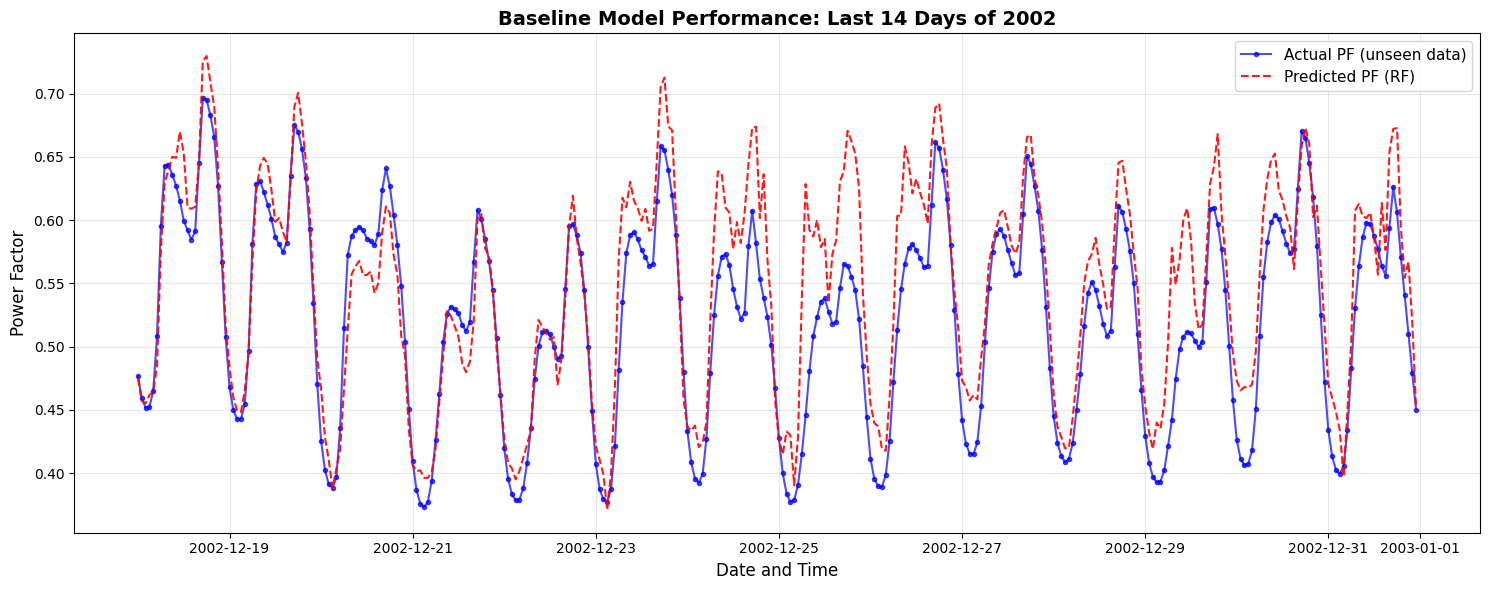

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Loading Dataset
print("Loading dataset...")
df = pd.read_csv("dataset_ml_pronto.csv", parse_dates=["timestamp"])

# 2. Selecting Features (Input) and Target (Output)
# Using weather and cyclic/categorical temporal variables
features = ['temperature', 'day_of_week', 'is_weekend', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos']
X = df[features]
y = df['power_factor']

# 3. Temporal Split (Strict: Training 2000-2001, Test 2002)
print("Splitting data into Training (past) and Test (future)...")
train_mask = df['timestamp'] < '2002-01-01'
test_mask = df['timestamp'] >= '2002-01-01'

X_train, y_train = X[train_mask], y[train_mask]
X_test, y_test = X[test_mask], y[test_mask]

print(f"Training data: {len(X_train)} hours (Years 2000-2001)")
print(f"Test data: {len(X_test)} hours (Year 2002)")

# 4. Training the Random Forest Baseline
print("\nTraining the Model... (this may take 10 to 30 seconds)")
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# 5. Prediction and Evaluation on 2002
y_pred = rf_model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\n--- BASELINE RESULTS (RANDOM FOREST) ---")
print(f"MAE (Mean Absolute Error): {mae:.4f}")
print(f"RMSE (Root Mean Squared Error): {rmse:.4f}")
print(f"R² (Coefficient of Determination): {r2:.4f}")

# 6. Feature Importance Analysis
feature_imp = pd.Series(rf_model.feature_importances_, index=features).sort_values(ascending=False)
print("\n--- FEATURE IMPORTANCE ---")
print(feature_imp.round(4))

# 7. Plot: Real vs Predicted Comparison (Last 5 Days of 2002)
plt.figure(figsize=(15, 6))
plot_hours = 24*14 # 24h * 14 days

# Extracting the last 5 days using negative indexing (-plot_hours:)
timestamps_plot = df.loc[test_mask, 'timestamp'].iloc[-plot_hours:]
y_test_plot = y_test.iloc[-plot_hours:]
y_pred_plot = y_pred[-plot_hours:]

plt.plot(timestamps_plot, y_test_plot, label='Actual PF (unseen data)', color='blue', marker='o', markersize=3, alpha=0.7)
plt.plot(timestamps_plot, y_pred_plot, label='Predicted PF (RF)', color='red', linestyle='dashed', alpha=0.9)
plt.title('Baseline Model Performance: Last 14 Days of 2002', fontsize=14, fontweight='bold')
plt.xlabel('Date and Time', fontsize=12)
plt.ylabel('Power Factor', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('rf_baseline_last_14_days.png', dpi=300) # Salvataggio automatico ad alta risoluzione
plt.show()

Preparing data with memory (Lags)...
Validation start date (Entire 2002): 2002-01-01 00:00:00
Training hours (2000-2001): 17352
Validation hours (Entire 2002): 8760

Training in progress...

--- FINAL VALIDATION RESULTS (ENTIRE YEAR 2002) ---
MAE: 0.0070
R² Score: 0.9922

✅ Model (pf_mlp_model_final.pkl) saved successfully!
✅ Scaler (pf_scaler.pkl) saved successfully!
✅ Plot data (final_validation_results.csv) exported successfully

Generating plot zoomed in on the last 14 days of 2002...


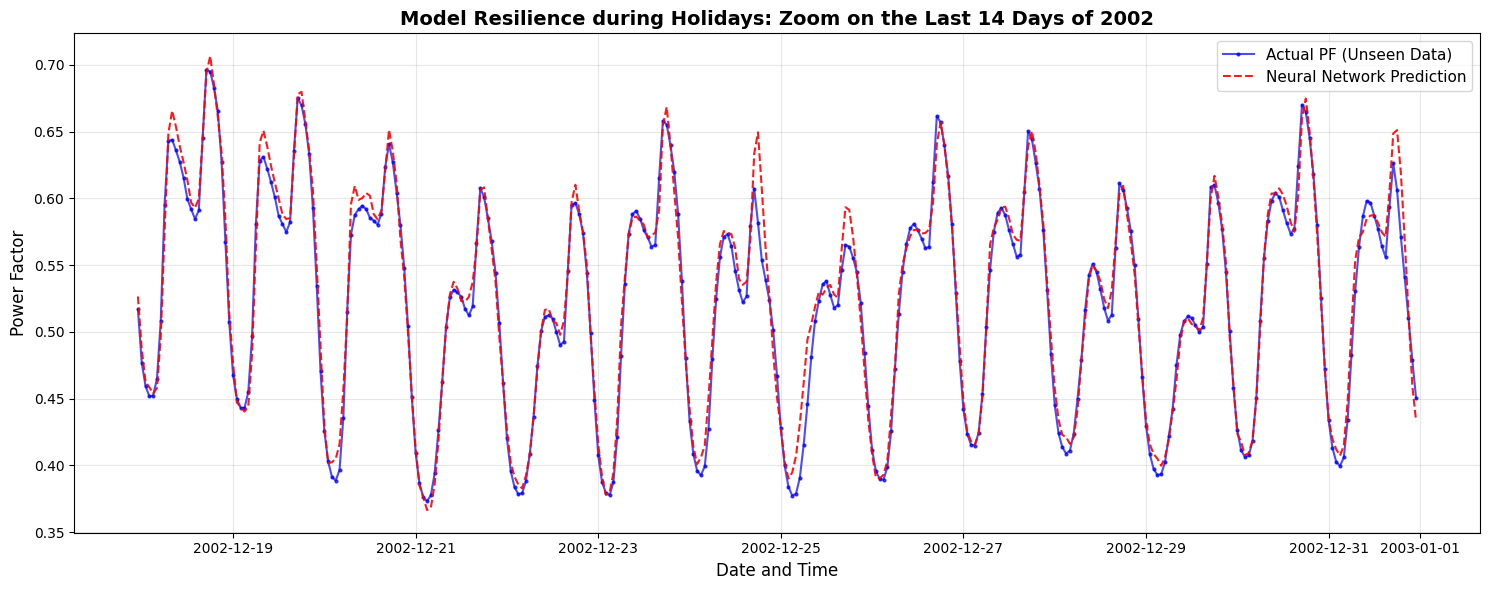


Calculating Permutation Feature Importance (this might take a few seconds)...

--- NEURAL NETWORK FEATURE IMPORTANCE ---
    Feature  Importance  Std_Dev
  pf_lag_1h    1.635208 0.022411
   hour_sin    0.075765 0.001293
   hour_cos    0.069560 0.001278
  month_cos    0.047303 0.000767
  month_sin    0.035582 0.000377
pf_lag_168h    0.019277 0.000566
 pf_lag_24h    0.016229 0.000573
temperature    0.013385 0.000164
day_of_week    0.007631 0.000180
 is_weekend    0.007630 0.000273


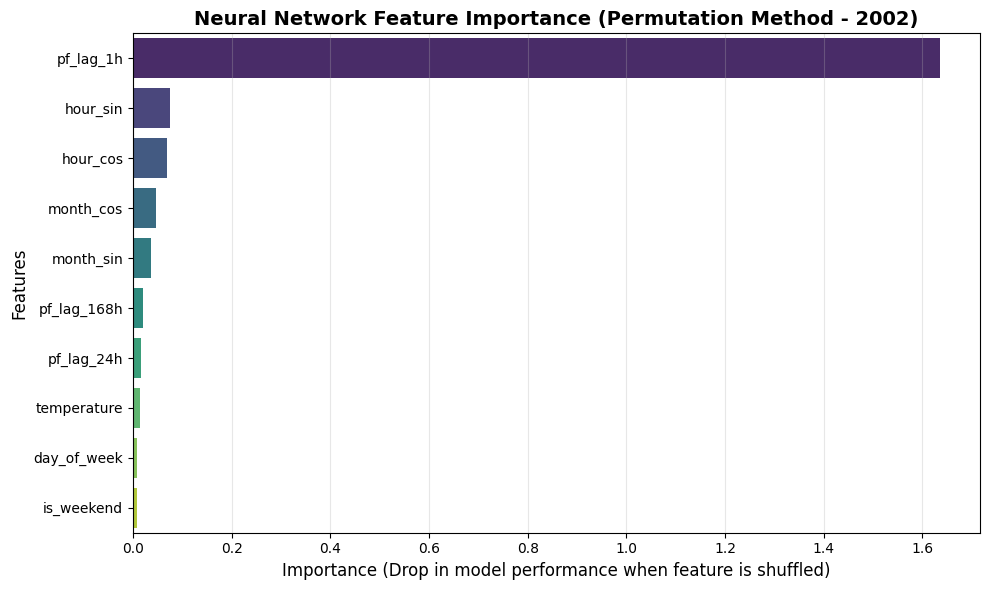

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance 
import joblib

# 1. Load Data and Prepare Lag Features (Memory)
print("Preparing data with memory (Lags)...")
df = pd.read_csv("dataset_ml_pronto.csv", parse_dates=["timestamp"])
df['pf_lag_1h'] = df['power_factor'].shift(1)
df['pf_lag_24h'] = df['power_factor'].shift(24)
df['pf_lag_168h'] = df['power_factor'].shift(168)
df = df.dropna().reset_index(drop=True)

# 2. Define Time Split (Training: 2000-2001, Validation: Entire 2002)
date_limit = pd.to_datetime('2002-01-01')
end_date = df['timestamp'].max()

print(f"Validation start date (Entire 2002): {date_limit}")

# 3. Data Splitting
features = ['temperature', 'day_of_week', 'is_weekend', 'hour_sin', 'hour_cos', 
            'month_sin', 'month_cos', 'pf_lag_1h', 'pf_lag_24h', 'pf_lag_168h']

X_train = df[df['timestamp'] < date_limit][features]
y_train = df[df['timestamp'] < date_limit]['power_factor']

X_val = df[df['timestamp'] >= date_limit][features]
y_val = df[df['timestamp'] >= date_limit]['power_factor']

print(f"Training hours (2000-2001): {len(X_train)}")
print(f"Validation hours (Entire 2002): {len(X_val)}")

# 4. Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# 5. Neural Network Training
print("\nTraining in progress...")
mlp_final = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    max_iter=1000,
    random_state=42,
    early_stopping=True
)

mlp_final.fit(X_train_scaled, y_train)

# 6. Predictions and Evaluation (On the ENTIRE 2002)
y_pred = mlp_final.predict(X_val_scaled)
mae = mean_absolute_error(y_val, y_pred)
r2 = r2_score(y_val, y_pred)

print("\n--- FINAL VALIDATION RESULTS (ENTIRE YEAR 2002) ---")
print(f"MAE: {mae:.4f}")
print(f"R² Score: {r2:.4f}")

# 7. Save Model and Scaler
joblib.dump(mlp_final, 'pf_mlp_model_final.pkl')
joblib.dump(scaler, 'pf_scaler.pkl')

# Save exact results for thesis plots
df_results = pd.DataFrame({
    'timestamp': df.loc[df['timestamp'] >= date_limit, 'timestamp'],
    'actual_pf': y_val,
    'predicted_pf': y_pred
})
df_results.to_csv('final_validation_results.csv', index=False)

print("\n✅ Model (pf_mlp_model_final.pkl) saved successfully!")
print("✅ Scaler (pf_scaler.pkl) saved successfully!")
print("✅ Plot data (final_validation_results.csv) exported successfully")

# 8. Plot Validation Results (ZOOM ON LAST 14 DAYS)
print("\nGenerating plot zoomed in on the last 14 days of 2002...")
plot_start_date = end_date - pd.Timedelta(days=14)
df_plot = df_results[df_results['timestamp'] >= plot_start_date]

plt.figure(figsize=(15, 6))
plt.plot(df_plot['timestamp'], df_plot['actual_pf'], label='Actual PF (Unseen Data)', color='blue', marker='o', markersize=2, alpha=0.7)
plt.plot(df_plot['timestamp'], df_plot['predicted_pf'], label='Neural Network Prediction', color='red', linestyle='--', alpha=0.9)
plt.title('Model Resilience during Holidays: Zoom on the Last 14 Days of 2002', fontsize=14, fontweight='bold')
plt.xlabel('Date and Time', fontsize=12)
plt.ylabel('Power Factor', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('nn_holiday_effect_zoom.png', dpi=300)
plt.show()

# --- NUOVA SEZIONE: PERMUTATION FEATURE IMPORTANCE (Sull'intero 2002) ---
print("\nCalculating Permutation Feature Importance (this might take a few seconds)...")
perm_importance = permutation_importance(mlp_final, X_val_scaled, y_val, n_repeats=10, random_state=42)

feature_importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': perm_importance.importances_mean,
    'Std_Dev': perm_importance.importances_std
}).sort_values(by='Importance', ascending=False)

print("\n--- NEURAL NETWORK FEATURE IMPORTANCE ---")
print(feature_importance_df.to_string(index=False))

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', hue='Feature', data=feature_importance_df, palette='viridis', legend=False)
plt.title('Neural Network Feature Importance (Permutation Method - 2002)', fontsize=14, fontweight='bold')
plt.xlabel('Importance (Drop in model performance when feature is shuffled)', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('nn_feature_importance_2002.png', dpi=300)
plt.show()
# ---------------------------------------------------

Loading final validation results...


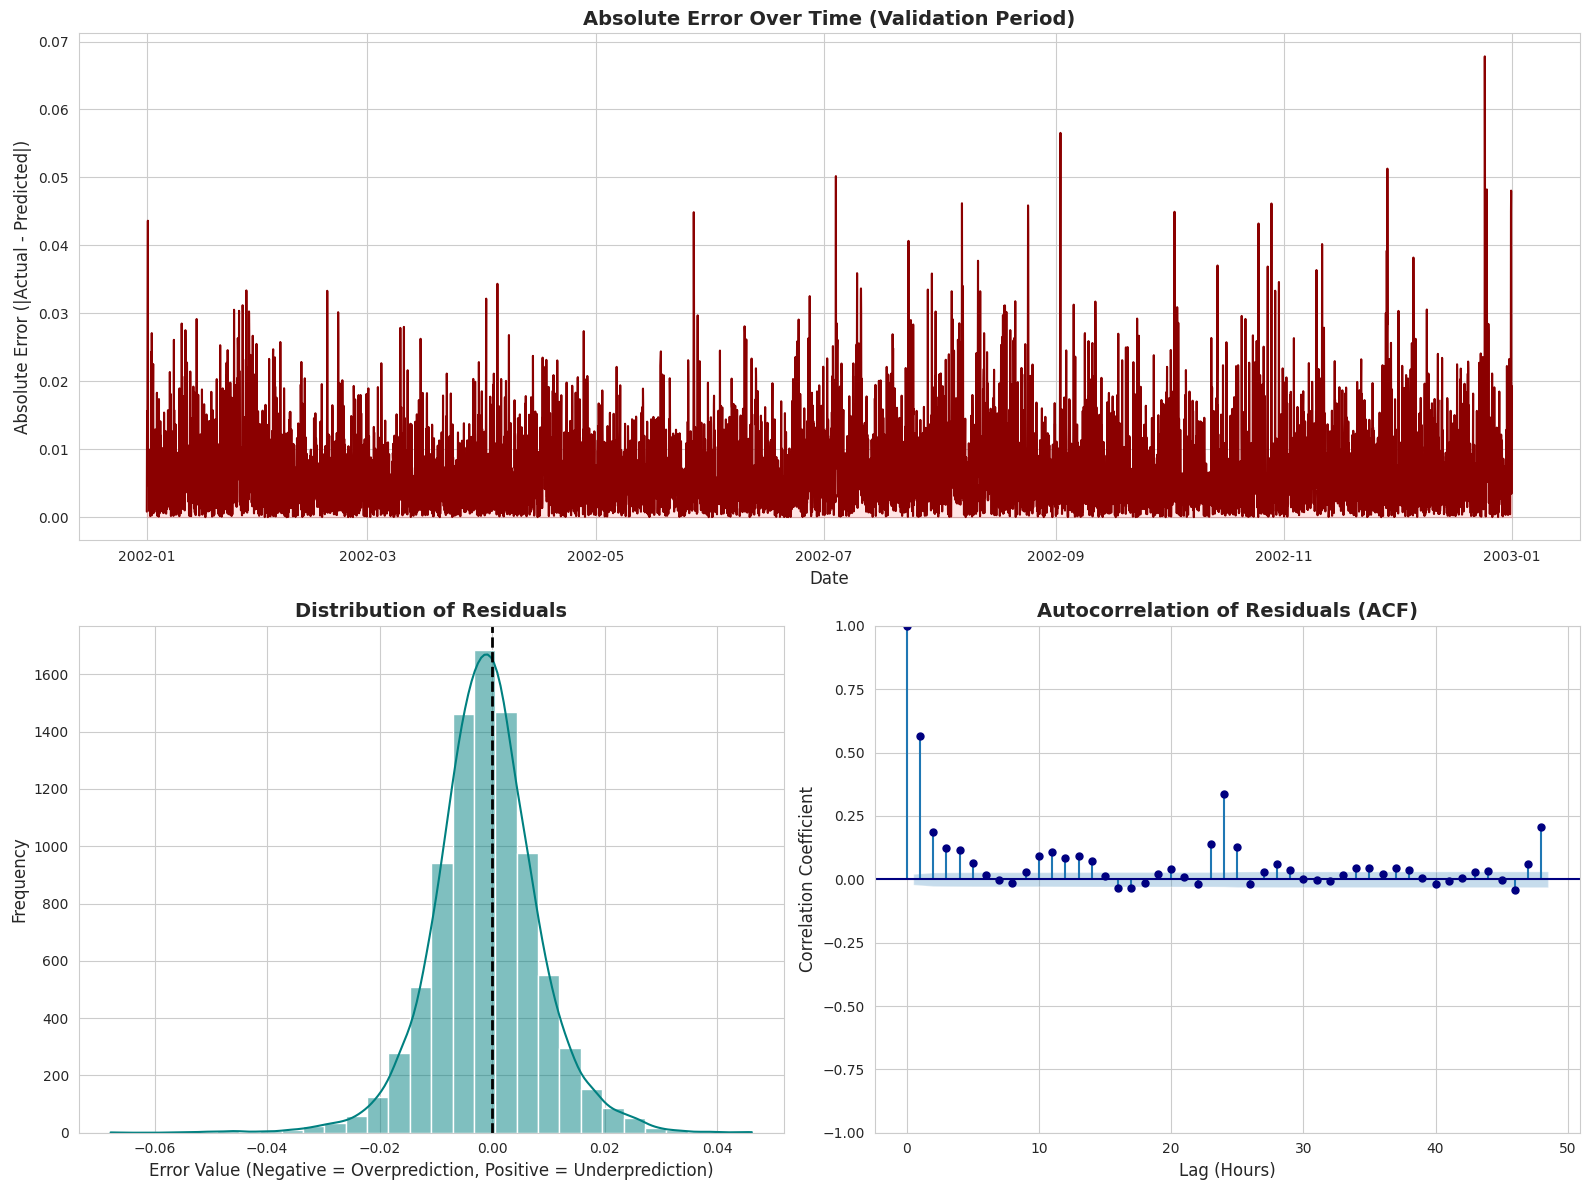


✅ Error Analysis complete. High-resolution image saved as 'error_analysis_dashboard.png'


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
import seaborn as sns

# 1. Load the results we saved earlier
print("Loading final validation results...")
df_res = pd.read_csv('final_validation_results.csv', parse_dates=['timestamp'])

# 2. Calculate Residuals and Absolute Error
df_res['residual'] = df_res['actual_pf'] - df_res['predicted_pf']
df_res['absolute_error'] = np.abs(df_res['residual'])

# Set up a beautiful, publication-ready figure with 3 subplots
fig = plt.figure(figsize=(16, 12))
sns.set_style("whitegrid")

# --- PLOT 1: Absolute Error Over Time ---
ax1 = plt.subplot(2, 1, 1)
ax1.plot(df_res['timestamp'], df_res['absolute_error'], color='darkred', linewidth=1.5)
ax1.fill_between(df_res['timestamp'], df_res['absolute_error'], 0, color='red', alpha=0.1)
ax1.set_title('Absolute Error Over Time (Validation Period)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Absolute Error (|Actual - Predicted|)', fontsize=12)
ax1.set_xlabel('Date', fontsize=12)

# --- PLOT 2: Error Distribution (Histogram) ---
ax2 = plt.subplot(2, 2, 3)
sns.histplot(df_res['residual'], kde=True, color='teal', ax=ax2, bins=30)
ax2.axvline(x=0, color='black', linestyle='--', linewidth=2)
ax2.set_title('Distribution of Residuals', fontsize=14, fontweight='bold')
ax2.set_xlabel('Error Value (Negative = Overprediction, Positive = Underprediction)', fontsize=12)
ax2.set_ylabel('Frequency', fontsize=12)

# --- PLOT 3: Autocorrelation of Residuals (ACF) ---
ax3 = plt.subplot(2, 2, 4)
plot_acf(df_res['residual'], ax=ax3, lags=48, color='navy', alpha=0.05)
ax3.set_title('Autocorrelation of Residuals (ACF)', fontsize=14, fontweight='bold')
ax3.set_xlabel('Lag (Hours)', fontsize=12)
ax3.set_ylabel('Correlation Coefficient', fontsize=12)

plt.tight_layout()
plt.savefig('error_analysis_dashboard.png', dpi=300, bbox_inches='tight') # Saves a high-res image for the thesis!
plt.show()

print("\n✅ Error Analysis complete. High-resolution image saved as 'error_analysis_dashboard.png'")

--- CLASSIC MODELS VS MACHINE LEARNING BENCHMARK ---
1. Loading dataset...
Test start date (last 3 days): 2002-12-28 23:00:00

2. Training ARMAX model (Order 2,0,2) ... This might take 1-2 minutes.
Predicting with ARMAX...

3. Training Simple ARIMA model (Order 2,0,2) ...
Predicting with Simple ARIMA...

--- PERFORMANCE COMPARISON (3 DAYS FORECAST) ---
ARMAX -> R² Score: -10.4563 | MAE: 0.2322
ARIMA -> R² Score: -7.8454 | MAE: 0.2069
MLP (Neural Net) -> R² Score: ~0.9922 | MAE: ~0.0070 (From previous run)


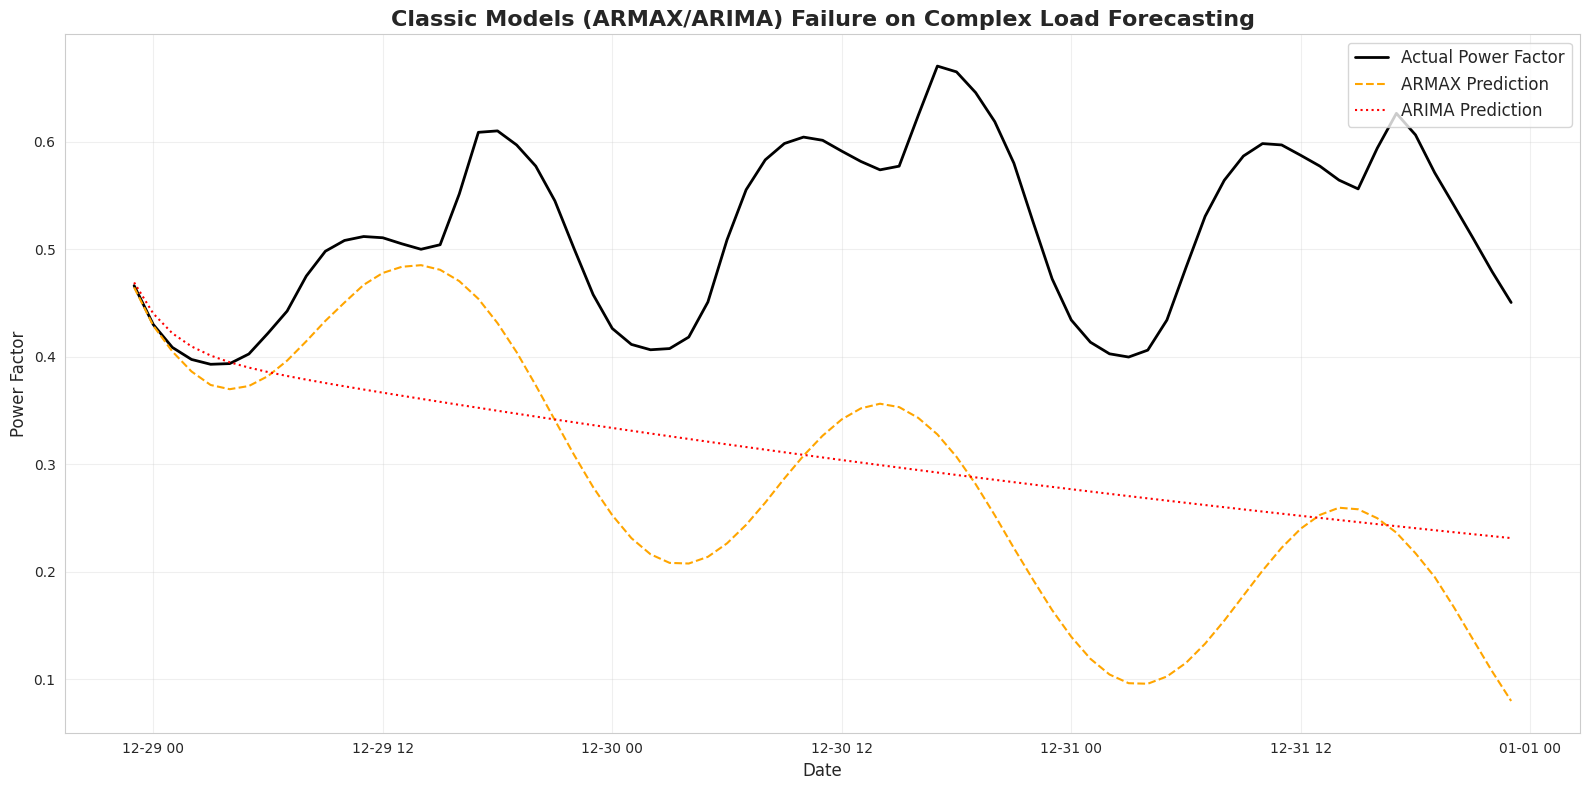


✅ Benchmark complete! See how the classic models likely flatline or drift off target. If classic models don't continuosly check and adjust the prediciton this is the result.


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, r2_score
import warnings
warnings.filterwarnings("ignore") # Nasconde i warning noiosi di statsmodels

print("--- CLASSIC MODELS VS MACHINE LEARNING BENCHMARK ---")

# 1. Load the clean dataset we generated earlier
print("1. Loading dataset...")
df = pd.read_csv("dataset_ml_pronto.csv", parse_dates=["timestamp"])

# Set index to timestamp for statsmodels
df.set_index('timestamp', inplace=True)

# 2. Define the 50-Day Hold-Out Validation Split
test_days = 3
date_limit = df.index.max() - pd.Timedelta(days=test_days)

print(f"Test start date (last {test_days} days): {date_limit}")

# 3. Prepare Data for Classic Models
# We use only exogenous variables (NO manual lags, ARIMA does its own lagging)
exog_features = ['temperature', 'hour_sin', 'hour_cos', 'day_of_week', 'is_weekend']

# CRITICAL: Classic models are extremely slow. We train them ONLY on the 30 days prior to the test.
train_start_for_arima = date_limit - pd.Timedelta(days=365)

train_data = df[(df.index >= train_start_for_arima) & (df.index < date_limit)]
test_data = df[df.index >= date_limit]

y_train_classic = train_data['power_factor']
X_train_classic = train_data[exog_features]

y_test_classic = test_data['power_factor']
X_test_classic = test_data[exog_features]

# --- MODEL 1: ARMAX (ARIMA + Exogenous variables, no complex seasonality) ---
print("\n2. Training ARMAX model (Order 2,0,2) ... This might take 1-2 minutes.")
# p=2 (looks back 2 hours), d=0 (stationary), q=2 (moving average 2 hours)
armax_model = SARIMAX(endog=y_train_classic, exog=X_train_classic, order=(2, 0, 2))
armax_results = armax_model.fit(disp=False)

print("Predicting with ARMAX...")
armax_predictions = armax_results.predict(start=y_test_classic.index[0], end=y_test_classic.index[-1], exog=X_test_classic)

# --- MODEL 2: SIMPLE ARIMA (No exogenous, just pure time series) ---
print("\n3. Training Simple ARIMA model (Order 2,0,2) ...")
arima_model = SARIMAX(endog=y_train_classic, order=(2, 0, 2))
arima_results = arima_model.fit(disp=False)

print("Predicting with Simple ARIMA...")
# Simple ARIMA just forecasts forward (it will likely flatline over 50 days)
arima_predictions = arima_results.predict(start=y_test_classic.index[0], end=y_test_classic.index[-1])

# --- EVALUATION ---
print("\n--- PERFORMANCE COMPARISON (3 DAYS FORECAST) ---")
metrics = []

# ARMAX Evaluation
r2_armax = r2_score(y_test_classic, armax_predictions)
mae_armax = mean_absolute_error(y_test_classic, armax_predictions)
print(f"ARMAX -> R² Score: {r2_armax:.4f} | MAE: {mae_armax:.4f}")

# ARIMA Evaluation
r2_arima = r2_score(y_test_classic, arima_predictions)
mae_arima = mean_absolute_error(y_test_classic, arima_predictions)
print(f"ARIMA -> R² Score: {r2_arima:.4f} | MAE: {mae_arima:.4f}")

# MLP
print(f"MLP (Neural Net) -> R² Score: ~0.9922 | MAE: ~0.0070 (From previous run)")

# --- VISUALIZATION ---
plt.figure(figsize=(16, 8))
sns.set_style("whitegrid")

# Let's plot just the first week of the 50 days so it's readable
plot_limit = 24 * 7 
plt.plot(y_test_classic.index[:plot_limit], y_test_classic[:plot_limit], label='Actual Power Factor', color='black', linewidth=2)
plt.plot(y_test_classic.index[:plot_limit], armax_predictions[:plot_limit], label='ARMAX Prediction', color='orange', linestyle='--')
plt.plot(y_test_classic.index[:plot_limit], arima_predictions[:plot_limit], label='ARIMA Prediction', color='red', linestyle=':')

plt.title('Classic Models (ARMAX/ARIMA) Failure on Complex Load Forecasting', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Power Factor', fontsize=12)
plt.legend(loc='upper right', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('classic_models_comparison.png', dpi=300)
plt.show()

print("\n✅ Benchmark complete! See how the classic models likely flatline or drift off target. If classic models don't continuosly check and adjust the prediciton this is the result.")